In [40]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2
import warnings
import logging

# 1. 彻底屏蔽 Matplotlib 的字体找不到警告
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

# 恢复默认设置
plt.rcParams['axes.unicode_minus'] = False
%config InlineBackend.figure_format = 'retina'

def process_and_analyze_tumor_evolution(file_2024, file_2025, 
                                        output_dir='./',         
                                        dp_threshold=50, 
                                        delta_threshold=0.15,
                                        output_plot_name='Tumor_Evolution_Plot.png'):
    """
    全流程分析肿瘤克隆演化：
    1. 输出 Excel：完全保留原文件所有行。
       新增列逻辑：
       - 自身被过滤 -> 'Filter'
       - 自身有效且对方有效文件中有 -> 'Yes'
       - 自身有效但对方有效文件中无 -> 'No'
    2. 画图：仅基于通过过滤的有效突变进行分析。
    """
    
    # 0. 基础设置
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"📁 目标文件夹不存在，已自动创建: {output_dir}")
        
    plot_path = os.path.join(output_dir, output_plot_name)
    
    # 获取文件名用于列名
    base_name_24 = os.path.splitext(os.path.basename(file_2024))[0]
    base_name_25 = os.path.splitext(os.path.basename(file_2025))[0]
    
    # 2. 拼接新的文件名 (注意加上 .xlsx 后缀)
    out_excel_24 = os.path.join(output_dir, f"{base_name_24}_merge_check.xlsx")
    out_excel_25 = os.path.join(output_dir, f"{base_name_25}_merge_check.xlsx")
    
    target_sheets = ['low scale variants', 'Large scale variants']
    
    # ==========================================
    # 1. 读取全量数据 (不丢弃任何行)
    # ==========================================
    def load_raw_data(filepath):
        dfs = []
        for sheet in target_sheets:
            try:
                df = pd.read_excel(filepath, sheet_name=sheet)
                df['Source_Sheet'] = sheet # 标记来源，用于最后还原 Sheet
                dfs.append(df)
            except ValueError:
                print(f"⚠️ 警告: 文件 {filepath} 中找不到 sheet '{sheet}'")
        return pd.concat(dfs, ignore_index=True)

    print("⏳ 正在读取 2024 全量数据...")
    raw_df_24 = load_raw_data(file_2024)
    print("⏳ 正在读取 2025 全量数据...")
    raw_df_25 = load_raw_data(file_2025)
    
    # ==========================================
    # 2. 定义过滤逻辑并获取有效 Key
    # ==========================================
    def get_filter_mask(df):
        # 深度转数值
        dp_numeric = pd.to_numeric(df['Tumor_DP'], errors='coerce').fillna(0)
        # VarScan 转字符串大写
        varscan_str = df['VarScan_Support'].astype(str).str.strip().str.upper()
        
        mask = (
            (df['Primary_Status'] == 'Somatic') & 
            (dp_numeric > dp_threshold) & 
            (varscan_str == 'TRUE')
        )
        return mask

    # 计算 24 和 25 的有效行掩码
    mask_24 = get_filter_mask(raw_df_24)
    mask_25 = get_filter_mask(raw_df_25)
    
    # 获取“通过过滤的有效 VariantKey 集合”
    valid_keys_24 = set(raw_df_24[mask_24]['VariantKey'])
    valid_keys_25 = set(raw_df_25[mask_25]['VariantKey'])
    
    # ==========================================
    # 3. 核心逻辑：打标签并输出 Excel
    # ==========================================
    # 定义标签函数
    def assign_status(row_mask, row_key, other_valid_keys):
        if not row_mask:
            return 'Filter' # 自身条件不满足
        elif row_key in other_valid_keys:
            return 'Yes'    # 自身满足，且对方也有
        else:
            return 'No'     # 自身满足，但对方没有

    # 生成列名
    col_name_24 = f"是否在_{base_name_25}_中"
    col_name_25 = f"是否在_{base_name_24}_中"

    # 为 2024 打标签
    raw_df_24[col_name_24] = [
        assign_status(m, k, valid_keys_25) 
        for m, k in zip(mask_24, raw_df_24['VariantKey'])
    ]
    
    # 为 2025 打标签
    raw_df_25[col_name_25] = [
        assign_status(m, k, valid_keys_24) 
        for m, k in zip(mask_25, raw_df_25['VariantKey'])
    ]
    
    # 保存 Excel (按原 Sheet 拆分)
    def save_excel(df, path):
        with pd.ExcelWriter(path) as writer:
            for sheet in target_sheets:
                # 提取对应 sheet 的数据
                sheet_data = df[df['Source_Sheet'] == sheet].copy()
                # 删除辅助列 Source_Sheet，还原原表结构（只多了一列 Check）
                sheet_data.drop(columns=['Source_Sheet'], inplace=True)
                sheet_data.to_excel(writer, sheet_name=sheet, index=False)

    save_excel(raw_df_24, out_excel_24)
    save_excel(raw_df_25, out_excel_25)
    print(f"✅ Excel 输出完成 (含 Filter 行):\n   -> {out_excel_24}\n   -> {out_excel_25}")

    # ==========================================
    # 4. 准备画图数据 (仅提取 Valid 的行进行分析)
    # ==========================================
    # 这里的 df_24 和 df_25 是专门用来画图的“干净数据”
    df_24_clean = raw_df_24[mask_24].copy()
    df_25_clean = raw_df_25[mask_25].copy()
    
    # 定义合并时的公共列
    common_cols = ['VariantKey', 'Source_Sheet', 'CHROM', 'POS', 'REF', 'ALT', 'Gene', 'Transcript', 'HGVSc', 'HGVSp', 'Consequence']
    
    # 重命名列以区分年份 (排除刚才加的 check 列)
    rename_24 = {c: f"{c}_2024" for c in df_24_clean.columns if c not in common_cols and c != col_name_24}
    rename_25 = {c: f"{c}_2025" for c in df_25_clean.columns if c not in common_cols and c != col_name_25}
    
    df_24_renamed = df_24_clean.drop(columns=[col_name_24]).rename(columns=rename_24)
    df_25_renamed = df_25_clean.drop(columns=[col_name_25]).rename(columns=rename_25)
    
    print("⏳ 正在计算可视化数据...")
    merged_df = pd.merge(df_24_renamed, df_25_renamed, on=common_cols, how='outer')
    
    merged_df['Tumor_VAF_2024'] = merged_df['Tumor_VAF_2024'].fillna(0.0)
    merged_df['Tumor_VAF_2025'] = merged_df['Tumor_VAF_2025'].fillna(0.0)

    # 判定状态
    conditions = [
        (merged_df['Tumor_VAF_2024'] > 0) & (merged_df['Tumor_VAF_2025'] > 0),
        (merged_df['Tumor_VAF_2024'] > 0) & (merged_df['Tumor_VAF_2025'] == 0),
        (merged_df['Tumor_VAF_2024'] == 0) & (merged_df['Tumor_VAF_2025'] > 0)
    ]
    choices = ['Shared', 'Lost in 2025', 'Acquired in 2025']
    merged_df['Mutation_Status'] = np.select(conditions, choices, default='Unknown')
    
    merged_df['VAF_Diff'] = (merged_df['Tumor_VAF_2025'] - merged_df['Tumor_VAF_2024']).abs()
    merged_df.sort_values('VAF_Diff', ascending=False, inplace=True)

    # ==========================================
    # 5. 可视化绘图
    # ==========================================
    fig = plt.figure(figsize=(18, 6))
    max_vaf = max(merged_df['Tumor_VAF_2024'].max(), merged_df['Tumor_VAF_2025'].max()) + 0.05
    palette = {'Shared': '#9b59b6', 'Lost in 2025': '#3498db', 'Acquired in 2025': '#e74c3c'}

    # 计算集合用于 Legend
    count_shared = len(valid_keys_24.intersection(valid_keys_25))
    count_lost = len(valid_keys_24 - valid_keys_25)
    count_acquired = len(valid_keys_25 - valid_keys_24)

    # 图 A: Venn
    ax1 = fig.add_subplot(131)
    venn2([valid_keys_24, valid_keys_25], ('2024 Tumor', '2025 Tumor'), ax=ax1, 
          set_colors=('#3498db', '#e74c3c'), alpha=0.7)
    ax1.set_title('A. Somatic Mutations Intersect', fontsize=14, fontweight='bold')

    # 图 B: Scatter
    ax2 = fig.add_subplot(132)
    sns.scatterplot(data=merged_df, x='Tumor_VAF_2024', y='Tumor_VAF_2025', 
                    hue='Mutation_Status', palette=palette, 
                    s=70, alpha=0.8, edgecolor='white', linewidth=0.5, ax=ax2)
    ax2.plot([0, max_vaf], [0, max_vaf], ls='--', color='gray', zorder=0, alpha=0.5)
    
    # 标注 Top 10
    for idx, row in merged_df.head(10).iterrows():
        ax2.annotate(str(row.get('Gene', '')), (row['Tumor_VAF_2024'], row['Tumor_VAF_2025']),
                     xytext=(4, 4), textcoords='offset points', fontsize=9, color='black')

    ax2.set_title('B. Clonal Evolution (VAF Dynamics)', fontsize=14, fontweight='bold')
    
    # 自定义 Legend
    handles, labels = ax2.get_legend_handles_labels()
    custom_handles, custom_labels = [], []
    for h, l in zip(handles, labels):
        if l == 'Shared': 
            custom_labels.append(f'Shared (n={count_shared})'); custom_handles.append(h)
        elif l == 'Lost in 2025': 
            custom_labels.append(f'Lost in 2025 (n={count_lost})'); custom_handles.append(h)
        elif l == 'Acquired in 2025': 
            custom_labels.append(f'Acquired in 2025 (n={count_acquired})'); custom_handles.append(h)
    ax2.legend(custom_handles, custom_labels, loc='upper left')

    # 图 C: Slope Graph
    ax3 = fig.add_subplot(133)
    sig_genes = merged_df[merged_df['VAF_Diff'] > delta_threshold] 

    for idx, row in sig_genes.iterrows():
        c = '#e74c3c' if row['Tumor_VAF_2025'] > row['Tumor_VAF_2024'] else '#3498db'
        ax3.plot([0, 1], [row['Tumor_VAF_2024'], row['Tumor_VAF_2025']], 
                 marker='o', markersize=6, color=c, linewidth=2, alpha=0.6)
        label = f"{row.get('Gene','')} ({str(row.get('HGVSp',''))})"
        ax3.text(1.03, row['Tumor_VAF_2025'], label, verticalalignment='center', fontsize=8, color=c)

    ax3.set_xticks([0, 1]); ax3.set_xticklabels(['2024', '2025'])
    ax3.set_xlim(-0.2, 1.8); ax3.set_ylim(-0.02, max_vaf)
    ax3.set_title(f'C. Significant Shifts (ΔVAF > {delta_threshold*100:.0f}%)', fontsize=14, fontweight='bold')
    ax3.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"✅ 图表绘制完成，PDF 已保存至:\n   -> {plot_path}")

⏳ 正在读取 2024 全量数据...
⏳ 正在读取 2025 全量数据...
✅ Excel 输出完成 (含 Filter 行):
   -> /home/jovyan/work/09.data_CCS_sdfyy/05.Result.Sakit2Neo/CS019_2025/reports/comparison/CS019_2024.Somatic_NeoPeptides_merge_check.xlsx
   -> /home/jovyan/work/09.data_CCS_sdfyy/05.Result.Sakit2Neo/CS019_2025/reports/comparison/CS019_2025.Somatic_NeoPeptides_merge_check.xlsx
⏳ 正在计算可视化数据...
✅ 图表绘制完成，PDF 已保存至:
   -> /home/jovyan/work/09.data_CCS_sdfyy/05.Result.Sakit2Neo/CS019_2025/reports/comparison/Tumor_Evolution_Plot.png


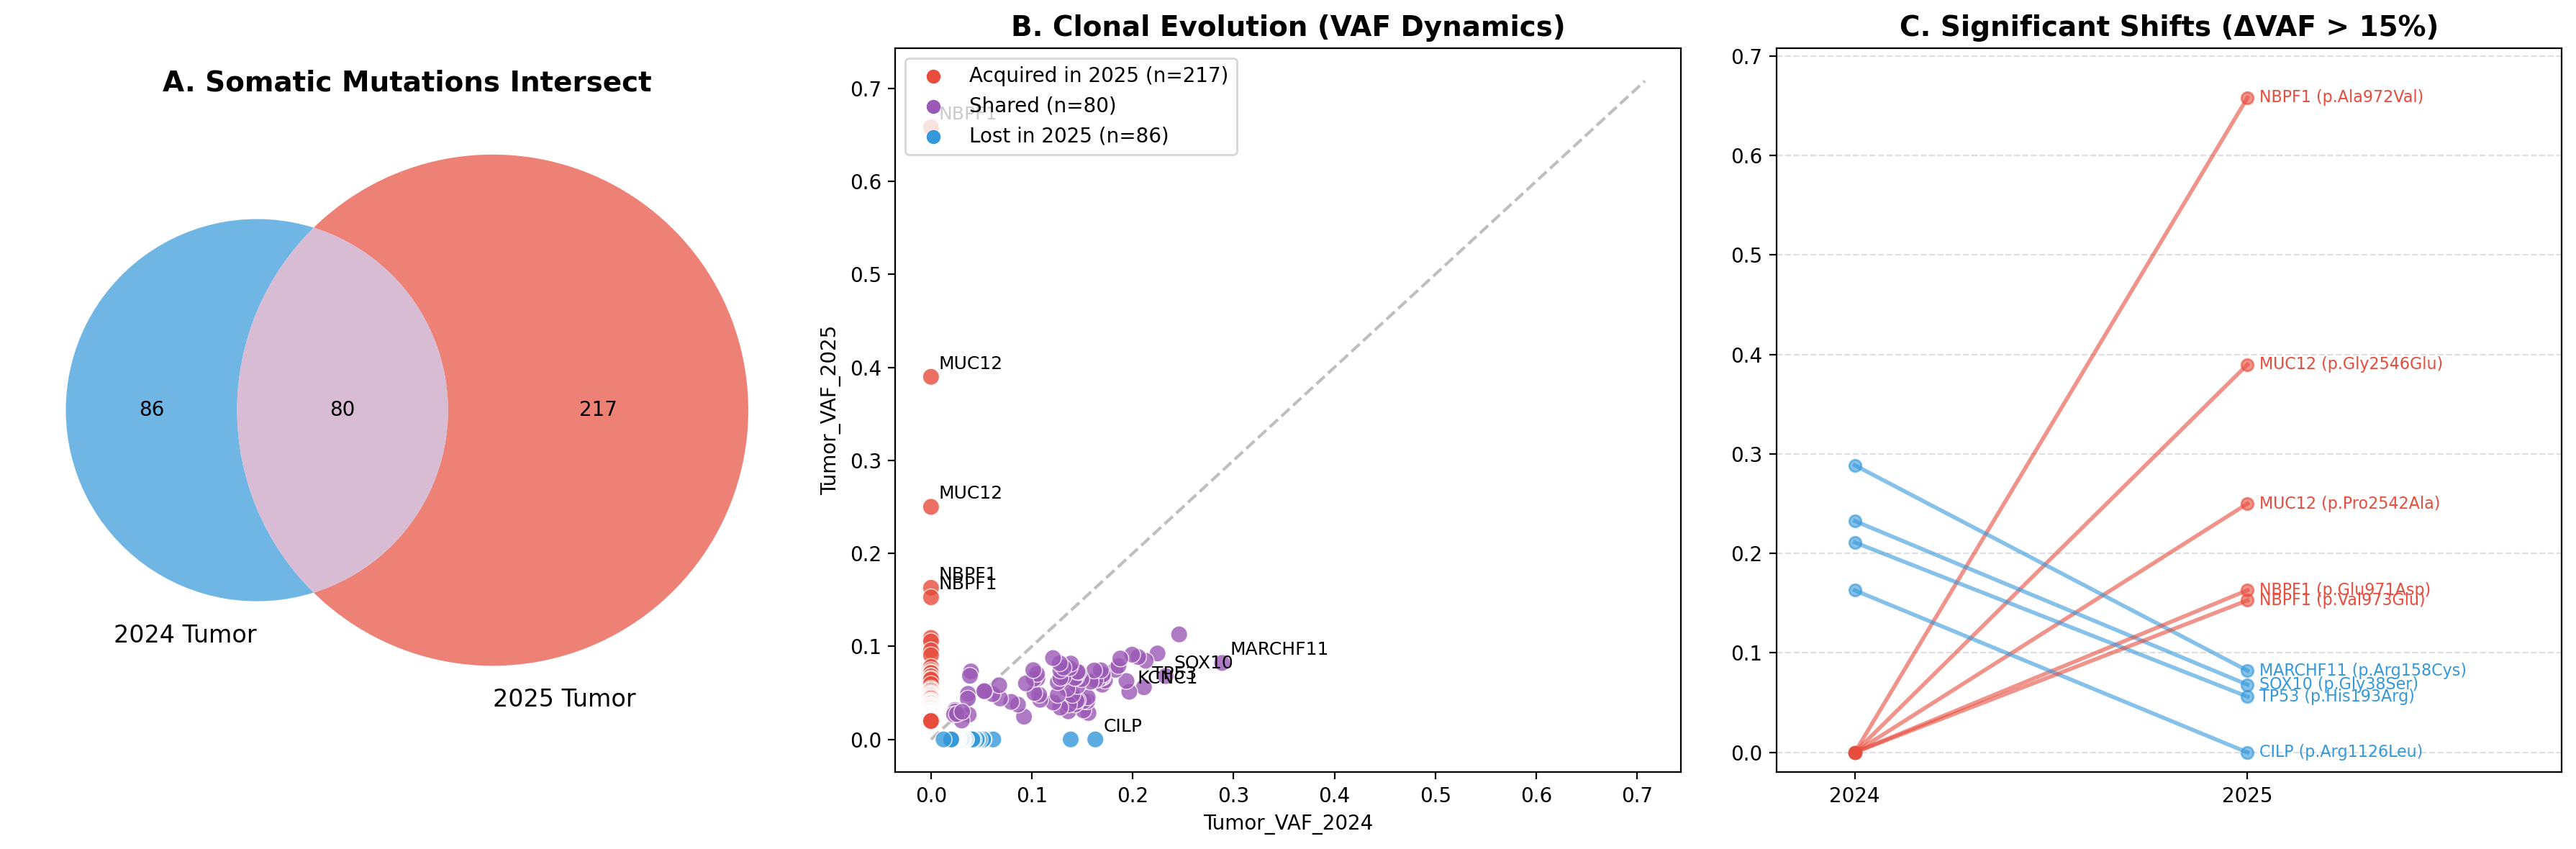

In [41]:
file_24 = '/home/jovyan/work/09.data_CCS_sdfyy/05.Result.Sakit2Neo/CS019_2024/reports/CS019_2024.Somatic_NeoPeptides.xlsx'
file_25 = '/home/jovyan/work/09.data_CCS_sdfyy/05.Result.Sakit2Neo/CS019_2025/reports/CS019_2025.Somatic_NeoPeptides.xlsx'
out_folder = '/home/jovyan/work/09.data_CCS_sdfyy/05.Result.Sakit2Neo/CS019_2025/reports/comparison/'

result_df = process_and_analyze_tumor_evolution(
    file_2024 = file_24,
    file_2025 = file_25,
    output_dir = out_folder,   # <--- 在这里指定文件夹
    dp_threshold = 50,
    delta_threshold = 0.15
)